<a href="https://colab.research.google.com/github/ARNAV2-4DEV/minorProject4/blob/main/minorProject4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (7043, 21)

--- Target Variable Distribution ---
No: 5174 (73.46%)
Yes: 1869 (26.54%)


/tmp/ipykernel_995/2668697243.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='Set2')


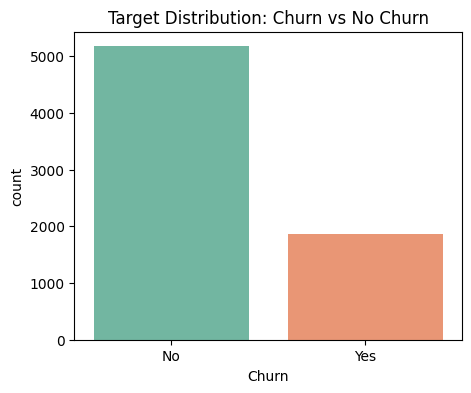

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load the dataset
df = pd.read_csv("/content/Telco-Customer-Churn.csv")
print(f"Dataset Shape: {df.shape}")

# Inspect target class imbalance
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("\n--- Target Variable Distribution ---")
for idx, count in churn_counts.items():
    print(f"{idx}: {count} ({churn_pct[idx]:.2f}%)")

# Visualization: Class Imbalance
plt.figure(figsize=(5, 4))
sns.countplot(x='Churn', data=df, palette='Set2')
plt.title('Target Distribution: Churn vs No Churn')

# Create the 'charts' directory if it doesn't exist
os.makedirs('charts', exist_ok=True)

plt.savefig('charts/target_distribution.png') # For submission package
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Handle Missing Values hidden as blank spaces in TotalCharges
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = df['TotalCharges'].astype(float)
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

# Drop unique identifier column
df.drop(columns=['customerID'], inplace=True)

# 2. Convert Target to Binary Numeric (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 3. Categorical Encoding (One-Hot Encoding with drop_first to avoid multicollinearity)
categorical_cols = df.select_dtypes(include=['object']).columns
df_processed = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 4. Feature-Target Separation
X = df_processed.drop(columns=['Churn'])
y = df_processed['Churn']

# 5. Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 6. Feature Scaling (Standardization)
# Crucial for Logistic Regression regularization (L2/C parameter)
scaler = StandardScaler()
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

/tmp/ipykernel_995/2463370054.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [9]:
from sklearn.linear_model import LogisticRegression

# Initializing Logistic Regression with hyperparameter justifications
# 'penalty'='l2': Ridge regularization to prevent overfitting on correlated features
# 'C'=1.0: Default inverse regularization strength
# 'solver'='lbfgs': Robust optimization solver for small to mid-sized datasets
model = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully.")

Logistic Regression Model Trained Successfully.


Accuracy Score: 0.8055

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



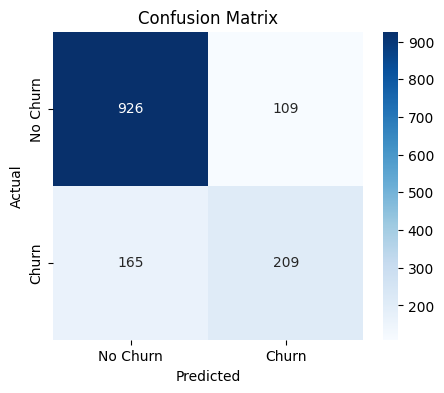

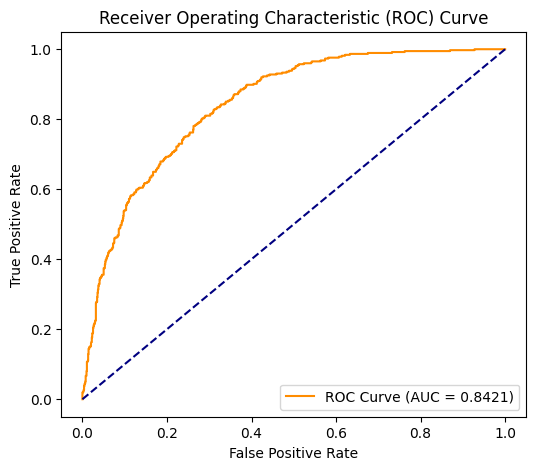

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, roc_auc_score

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# 1. Confusion Matrix & Accuracy
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy Score: {acc:.4f}\n")
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 2. Visualizing Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.savefig('charts/confusion_matrix.png')
plt.show()

# 3. ROC-AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.savefig('charts/roc_curve.png')
plt.show()

In [11]:
# Extracting Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("--- Top 3 Features Positively Impacting Churn (Increases Risk) ---")
print(coefficients.head(3))

print("\n--- Top 3 Features Negatively Impacting Churn (Reduces Risk/Protects) ---")
print(coefficients.tail(3))

--- Top 3 Features Positively Impacting Churn (Increases Risk) ---
                        Feature  Coefficient
10  InternetService_Fiber optic     1.190576
3                  TotalCharges     0.511378
23          StreamingMovies_Yes     0.380384

--- Top 3 Features Negatively Impacting Churn (Reduces Risk/Protects) ---
              Feature  Coefficient
24  Contract_One year    -0.690863
1              tenure    -1.237578
25  Contract_Two year    -1.337453
